# Introduction

This is the basic reproduction experiment for Yao et al., "Dynamic Word Embeddings for Evolving Semantic Discovery".
It is based on the source code provided in their
[GitHub repository](https://github.com/yifan0sun/DynamicWord2Vec)
and aims to simplify the experiment, update it to a modern Python setup, and ultimately validate the findings from the authors.

# Setup

## Imports

In [1]:
# file io
import scipy.io as sio

# machine learning
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import pandas as pd

# analyses and plots
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE

## Data setup
The experiment relies on files from the researchers dropbox folder. These files are saved in the data directory first.

In [2]:
%run ../setup/setup.py

Target data directory: /home/jovyan/Semantic-Embedding-Evolution/data
Data seems to be loaded already. Skipping download.


## Static variables

In [3]:
vocab_size = 20936 # number of words in vocab (11068100/20936 for ngram/nyt)
years = range(1990,2016) # total number of time points (20/range(27) for ngram/nyt)

raw_emb = sio.loadmat("../data/emb_static.mat")["emb"]
embeddings = torch.from_numpy(raw_emb).float()
trainhead = "../data/wordPairPMI_"

# Embedding training

## Dataset

In [4]:
class DynamicPMIDataset(Dataset):
    def __init__(self, time_steps, trainhead, vocab_size):
        self.time_steps = time_steps
        self.trainhead = trainhead
        self.vocab_size = vocab_size

    def __len__(self):
        return len(self.time_steps)

    def __getitem__(self, idx):
        t = self.time_steps[idx]
        df = pd.read_csv(f"{self.trainhead}{t}.csv")
        # Convert to sparse tensor or keep as dense if memory allows
        # For small vocab, dense is faster on GPU
        indices = torch.from_numpy(df.values[:, :2]).long()
        values = torch.from_numpy(df.values[:, 2]).float()
        return t, indices, values

## Model

In [5]:
class DynamicEmbeddingModel(nn.Module):
    def __init__(self, n_times, static_embeddings):
        super().__init__()
        n_vocab, r = static_embeddings.shape

        init_val = static_embeddings.unsqueeze(0).repeat(n_times, 1, 1)
        self.U = nn.Parameter(init_val.clone())
        self.V = nn.Parameter(init_val.clone())

    def forward(self, t, indices, values, lam, tau, gam):
            U_t = self.U[t]
            V_t = self.V[t]

            # 1. Reconstruction Loss (Signal)
            u_idx, v_idx = indices[:, 0], indices[:, 1]
            pred = torch.sum(U_t[u_idx] * V_t[v_idx], dim=1)
            recon_loss = torch.mean((values - pred)**2)

            # 2. Regularization (Penalty for magnitude)
            reg_loss = lam * (U_t.pow(2).mean() + V_t.pow(2).mean())

            # Temporal Smoothing
            temp_loss = 0
            if t > 0:
                temp_loss += tau * (U_t - self.U[t-1]).pow(2).mean()
            if t < self.U.size(0) - 1:
                temp_loss += tau * (U_t - self.U[t+1]).pow(2).mean()

            # 4. Alignment Constraint (Penalty for U/V difference)
            align_loss = gam * (U_t - V_t).pow(2).mean()

            return recon_loss + reg_loss + temp_loss + align_loss

## Hyperparameters

In [6]:
n_epochs = 5 # total passes over the data
lam = 10 # frob regularizer
tau = 100000  # smoothing regularizer
gam = 100 # forcing regularizer
r = 50  # rank
learning_rate = 1e-3

## Traning procedure

In [7]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = DynamicEmbeddingModel(len(years), embeddings).to(device)
optimizer = optim.Adam(model.parameters(), lr=learning_rate)
dataset = DynamicPMIDataset(range(len(years)), "../data/wordPairPMI_", vocab_size)
loader = DataLoader(dataset, batch_size=1)

In [8]:
for epoch in range(n_epochs):
    total_loss = 0
    for t, indices, values in loader:
        t, indices, values = t.to(device), indices.squeeze(0).to(device), values.squeeze(0).to(device)

        optimizer.zero_grad()
        loss = model(t.item(), indices, values, lam=lam, tau=tau, gam=gam)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    print(f"Epoch {epoch}, Loss: {total_loss/len(years)}")

Epoch 0, Loss: 7.336311890528752
Epoch 1, Loss: 7.595516149814312
Epoch 2, Loss: 10.027180378253643
Epoch 3, Loss: 14.251889412219708
Epoch 4, Loss: 25.797423179333027


# Output visualization

## Setup word to id mapping

In [9]:
with open('../data/wordlist.txt', 'r') as fid:
    wordlist = [line.strip() for line in fid]

word2Id = {word: i for i, word in enumerate(wordlist)}

## Example embedding over time

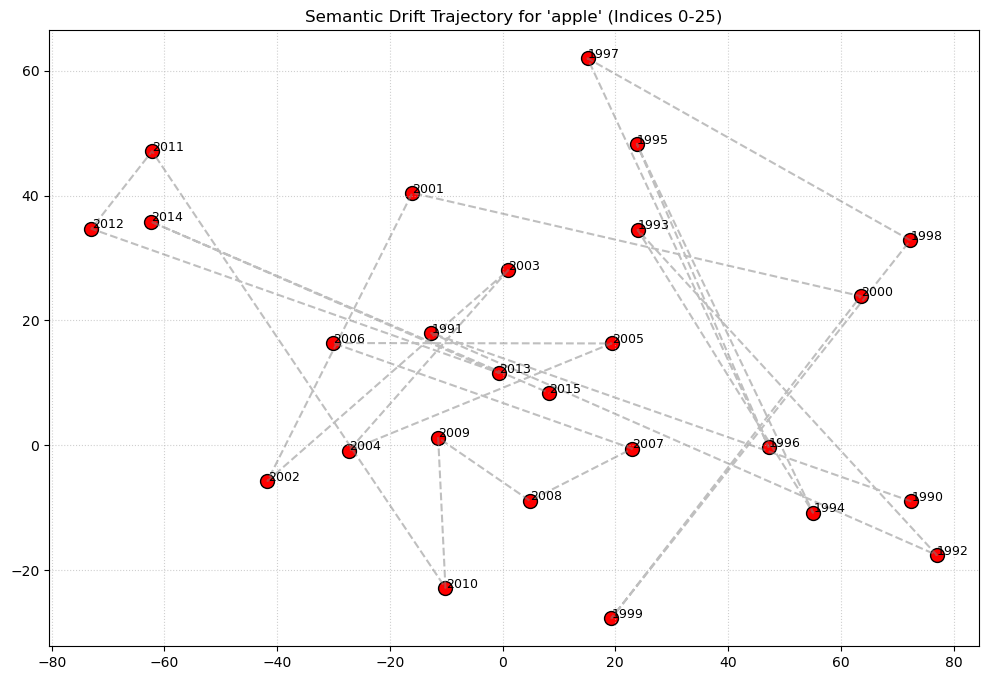

In [10]:
word = "apple"
word_idx = word2Id[word]

# generate embeddings
model.eval()
with torch.no_grad():
    embs = model.U[list(range(len(years))), word_idx, :].detach().cpu().numpy()

# reduce to 2 dimensions
tsne = TSNE(n_components=2, perplexity=5, random_state=42, init='pca')
Z = tsne.fit_transform(embs)

# plot
plt.figure(figsize=(12, 8))
plt.plot(Z[:, 0], Z[:, 1], linestyle='--', color='gray', alpha=0.5)

for i, year in enumerate(years):
    plt.scatter(Z[i, 0], Z[i, 1], color='red', s=100, edgecolors='black')
    plt.text(Z[i, 0] + 0.05, Z[i, 1] + 0.05, f"{year}", fontsize=9)

plt.title(f"Semantic Drift Trajectory for '{word}' (Indices 0-25)")
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()